In [7]:
import numpy as np
from models import DeepDLDS, SimpleNN
from datasets import CdLDSDataGenerator
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import plotly.graph_objects as go
import plotly.express as px
import util
import pandas as pd
from sklearn.decomposition import PCA

In [53]:
worm_states = np.load('data/worm_states.npy')
worm_data = np.load('data/worm_DS1_low.npy')
controls = np.load('controls.npy')

In [ ]:
# plot states
fig = 

In [51]:
# save first 3329 frames
worm_states = worm_states[:, :3329]
np.save('data/worm_DS1_low_states.npy', worm_states)

In [52]:
worm_states.shape

(2, 3329)

In [8]:
K = 2
control_size=1
generator = CdLDSDataGenerator(K=K, D_control=control_size, fix_point_change=True, eigenvalue_radius=0.94, set_seed=K)

time_points = 3000

# generate toy data
X = generator.generate_data(time_points, sigma=0.00)
if K == 1:
    states = torch.ones(time_points, 1).squeeze()
else:
    states = generator.states_#[1:]

# z-score normalization
# X = (X - X.mean(axis=0)) / X.std(axis=0)
np.save('data.npy', X)

X1 = torch.tensor(X[:, :-1], dtype=torch.float32)
X2 = torch.tensor(X[:, 1:], dtype=torch.float32)

In [9]:
px.line(X1.T)

In [14]:
st

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [17]:
# reconstruct the data from A, z, B and U
true_dynamics = generator.A
coeffs = generator.coefficients_
# one hot encoded states


#coeffs = np.zeros((K,len(st)))
#coeffs[st,np.arange(len(st))] = 1
B = generator.B
controls = generator.U_

#single step prediction
X_pred = np.zeros_like(X)
X_pred[:, 0] = X[:, 0]
for t in range(1, time_points):
    X_pred[:, t] = np.dstack([coeffs[i,t]*(f_i@X[:, t-1])+B[:]@controls[:, t-1] for i, f_i in enumerate(true_dynamics)]).sum(axis=2)

In [19]:
# reconstruct

X_pred2 = generator.multi_step_reconstruction(time_points, X[:, 0], true_dynamics, B, controls, st)

In [20]:
px.line(controls[:1].T)

In [21]:
px.line(X.T)

In [22]:
px.line(X_pred2.T)

In [26]:
px.line(generator.U_[:control_size].T)

In [29]:
np.save('controls.npy', generator.U_[:control_size])
np.save('states.npy', states)
np.save('As.npy', generator.A)
np.save('Bs.npy', generator.B)

In [30]:
util.plotting(generator.U_[:control_size].T)

In [35]:
bias = (generator.B@generator.U_)

In [36]:
util.plotting(X.T, plot_states=True, states=states)

In [37]:
# calculate the next time steps
X_test = []
for t in range(1, time_points):
    next_state = generator.A @ X[:, t-1]
    X_test.append(next_state)
#px.line(X2.T - np.array(X_test).reshape(-1,4)) #change unit

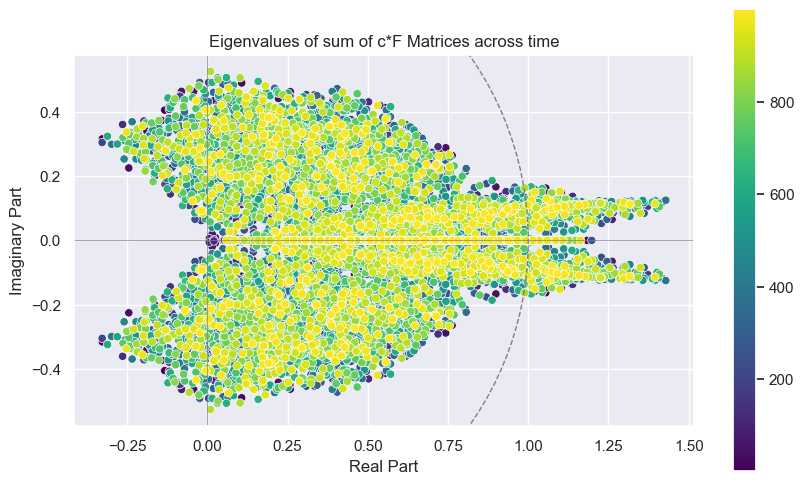

In [43]:
#%%script true
import numpy.linalg as linalg
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme()


plt.figure(figsize=(10, 6))

colors = {'1': 'red', '2': 'blue', '3': 'green', '4': 'purple'}  

data = []

for t in range(X2.shape[1]):
    f_sum = np.sum([simple_model.coeffs[idx].detach().numpy()[t]*f_i.effective_W().detach().numpy() for idx, f_i in enumerate(simple_model.F)], axis=0)
    eigenvalue = linalg.eig(f_sum)[0]
    df = pd.DataFrame({'real': np.real(eigenvalue), 'imag': np.imag(eigenvalue)})
    data.append(df)
              
df = pd.concat(data, keys=[str(i+1) for i in range(X2.shape[1])])

ax = sns.scatterplot(data=df, x='real', y='imag', alpha=1, hue=df.index.get_level_values(0), palette='viridis', marker='o', legend=False)

# Add a colorbar
norm = plt.Normalize(1, 999)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # Needed to trick colorbar into working with ScalarMappable

cbar = plt.colorbar(
    plt.cm.ScalarMappable(cmap='viridis', norm=norm),
    ax=plt.gca()
)

plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Eigenvalues of sum of c*F Matrices across time')

# Add a unit circle
unit_circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(unit_circle)

# Set equal scaling to ensure the unit circle is round
plt.gca().set_aspect('equal', adjustable='box')

# Show the plot
plt.show()
